# XGBoost - Cadre methodologique modulaire

Ce notebook applique un cadre methodologique reproductible et modulaire avec un modele XGBoost.

Il permet de :
- definir des profils (donnees, pretraitement, representation, modele, evaluation),
- executer une pipeline coherente pour l'approche A (agregation) ou B (fenetrage temporel),
- produire une fiche modele avec metriques et sorties graphiques.

In [2]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from xgb_pipeline.extract import add_target, load_csv_features, load_mat_matrix
from xgb_pipeline.pretraitement import apply_preprocess, prepare_splits_and_impute
from xgb_pipeline.models import fit_final_model, run_hyperparam_search
from xgb_pipeline.evaluation import (
    evaluate_by_subject,
    evaluate_robustness,
    evaluate_test_set,
    plot_feature_importance,
    plot_pca_if_classification,
)
from xgb_pipeline.reporting import build_model_card, save_outputs

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed globale: {SEED}")

ModuleNotFoundError: No module named 'matplotlib'

## 1) Profils modulaires

In [1]:
# Ajuster ces profils pour chaque experience
# Template source: xgb_pipeline/config.py (markdown a copier-coller)

DATA_PROFILE = {
    "source": "csv",
    "file_path": r"../data/Indicateurs calculés/FullTimeIndicatorsMat_2_1.csv",
    "subject_id_col": "Participant",
    "feature_columns": {
        0: "Time",
        1: "HMDPosX",
        2: "HMDPosY",
        3: "HMDPosZ",
        4: "RotX",
        5: "RotY",
        6: "RotZ",
        7: "SuggestedRotationX",
        8: "SuggestedRotationY",
        9: "SuggestedRotationZ",
        10: "LeftPupilDiameter",
        11: "RightPupilDiameter",
        12: "XGazeDirection",
        13: "YGazeDirection",
        14: "Confidence",
        15: "IsBoat",
        16: "XWorldPosition",
        17: "YWorldPosition",
    },
    "subject_id_count_hint": 42,
}

REPRESENTATION_PROFILE = {
    "approach": "A",
    "drop_time_column": True,
    "aggregated_stats": ["mean", "std", "min", "max", "median", "q25", "q75", "slope"],
    "window_length": 60,
    "window_stride": 30,
}

PREPROCESS_PROFILE = {
    "clip_quantiles": [0.01, 0.99],
    "imputation_strategy": "median",
    "drop_low_information_features": True,
    "min_valid_features": 1,
}

TARGET_PROFILE = {
    "subject_id_col": "Sujet",
    "source": "xlsx",
    "xlsx_path": r"../data/Questionnaires/FMS1_org.xlsx",
    "sheet_name": "Feuil1",
    "csv_path": r"../data/Indicateurs calculés/labels.csv",
    "target_col": "target",
    "target_mode": "fixed_minute",
    "target_minute": 14,
    "minute_start": 1,
    "minute_end": 14,
    "minute_columns": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
}

MODEL_PROFILE = {
    "task_type": "regression",  # classification / regression
    "split_method": "random",   # group / random
    "test_size": 0.20,
    "val_size": 0.20,
    "class_weight": "balanced",
    "random_state": SEED,
}

EVAL_PROFILE = {
    "robustness_noise_std": 0.01,
    "robustness_repeats": 5,
}

OUTPUT_PROFILE = {
    "output_dir": r"../outputs/xgboost_modulaire",
    "save_model_card": True,
}

print("Profils charges depuis la cellule notebook (template config.py)")
print("Data source :", DATA_PROFILE["source"])
print("Approche :", REPRESENTATION_PROFILE["approach"])
print("Tache :", MODEL_PROFILE["task_type"])
print("Target source :", TARGET_PROFILE["source"])
print("Mode cible :", TARGET_PROFILE.get("target_mode", "n/a"))

NameError: name 'SEED' is not defined

## 2) Fonctions utilitaires

In [ ]:
print("Les fonctions utilitaires sont maintenant fournies par xgb_pipeline.")
print("Modules disponibles : extract, pretraitement, models, evaluation, reporting")

Les fonctions utilitaires sont maintenant fournies par xgb_pipeline.
Modules disponibles : extract, pretraitement, models, evaluation, reporting


## 3) Construction de representation (Approche A ou B)

In [ ]:
if DATA_PROFILE["source"] == "csv":
    features_df = load_csv_features(DATA_PROFILE)
    print("Source CSV detectee: les features sont chargees telles quelles.")

elif DATA_PROFILE["source"] == "mat":
    mat_dict, data_matrix, subject_ids = load_mat_matrix(DATA_PROFILE)
    raise NotImplementedError(
        "Le chemin MAT doit maintenant etre orchestre via des fonctions dediees dans xgb_pipeline si necessaire."
    )

else:
    raise ValueError("DATA_PROFILE['source'] doit etre 'csv' ou 'mat'.")

print("Representation construite:", REPRESENTATION_PROFILE["approach"])
print("Shape:", features_df.shape)
display(features_df.head())

Source CSV detectee: les features sont chargees telles quelles.
Representation construite: A
Shape: (42, 33)


,subject_id,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,TotMovZ,...,%Pow01EyeX,%Pow01EyeY,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,0933,2.045607,6.865202,0.436337,0.559538,1.516248,0.555482,43817.868971,138099.627657,14293.572633,...,4.517809,9.398764,0.829681,9.398764,0.088689,386.938072,3.021157,3.045238,2.351190,1
2,7180bt,4.702907,4.793942,0.584512,1.132821,1.285857,0.966940,103894.677647,94351.104112,18464.361471,...,2.856991,2.050513,0.724361,2.050513,0.126805,1071.982238,3.387805,3.284950,6.017499,2
3,22009611,1.346416,1.383257,0.330014,0.355751,0.666079,0.259828,34238.265207,29168.731202,8550.312429,...,1.870839,3.411846,2.487630,3.411846,0.083754,375.050691,3.689561,3.902330,27.463789,3
4,ab0710,0.891186,1.231305,0.225509,0.157097,0.355557,0.305395,16093.269569,20608.057421,6433.611008,...,8.328613,6.377434,2.567120,6.377434,0.098363,155.945660,3.970180,3.844016,2.880952,4


## 4) Integration de la cible

In [ ]:
dataset_df = add_target(features_df, TARGET_PROFILE)

print("Dataset avec cible:", dataset_df.shape)
print("Apercu colonnes:", dataset_df.columns[:10].tolist())
display(dataset_df.head())

Dataset avec cible: (39, 34)
Apercu colonnes: ['subject_id', 'Amp01X', 'Amp01Y', 'Amp01Z', 'Amp04X', 'Amp04Y', 'Amp04Z', 'TotMovX', 'TotMovY', 'TotMovZ']


,subject_id,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,TotMovZ,...,%Pow01EyeY,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id,target
0,7180bt,4.702907,4.793942,0.584512,1.132821,1.285857,0.966940,103894.677647,94351.104112,18464.361471,...,2.050513,0.724361,2.050513,0.126805,1071.982238,3.387805,3.284950,6.017499,2,2.0
1,22009611,1.346416,1.383257,0.330014,0.355751,0.666079,0.259828,34238.265207,29168.731202,8550.312429,...,3.411846,2.487630,3.411846,0.083754,375.050691,3.689561,3.902330,27.463789,3,5.0
2,ab0710,0.891186,1.231305,0.225509,0.157097,0.355557,0.305395,16093.269569,20608.057421,6433.611008,...,6.377434,2.567120,6.377434,0.098363,155.945660,3.970180,3.844016,2.880952,4,12.0
3,am3001,1.750781,1.711415,0.686121,0.698874,0.615759,0.285633,39148.914312,32611.226299,15517.439364,...,4.286956,0.848972,4.286956,0.134579,281.906274,5.099959,5.169935,9.452316,5,10.0
4,AP1133,0.072603,0.050139,0.062497,0.145819,0.130945,0.202855,2596.752982,10290.089184,11665.798600,...,40.316251,3.937453,40.316251,0.046185,47.609290,3.776644,3.851565,3.096595,6,14.0


## 5) Pretraitement, split et preparation

In [ ]:
dataset_df, feature_cols = apply_preprocess(dataset_df, PREPROCESS_PROFILE)

prepared = prepare_splits_and_impute(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    preprocess_profile=PREPROCESS_PROFILE,
    model_profile=MODEL_PROFILE,
)

X_train_imp = prepared["X_train_imp"]
X_val_imp = prepared["X_val_imp"]
X_test_imp = prepared["X_test_imp"]
y_train = prepared["y_train"]
y_val = prepared["y_val"]
y_test = prepared["y_test"]
train_idx = prepared["train_idx"]
val_idx = prepared["val_idx"]
test_idx = prepared["test_idx"]
imputer = prepared["imputer"]

print("Dataset final:", dataset_df.shape)
print("Nombre de features:", len(feature_cols))
print("Split sizes -> train/val/test:", len(train_idx), len(val_idx), len(test_idx))

Dataset final: (39, 34)
Nombre de features: 31
Split sizes -> train/val/test: 23 8 8


## 6) Optimisation hyperparametres et entrainement

In [ ]:
best_params, results_df = run_hyperparam_search(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    model_profile=MODEL_PROFILE,
)

display(results_df.head(10))
print("Best params:", best_params)

final_model = fit_final_model(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    best_params=best_params,
    model_profile=MODEL_PROFILE,
)

,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,val_rmse,val_r2
0,1.0,0.10,6,100,0.8,3.287295,0.423183
1,1.0,0.10,6,300,0.8,3.293201,0.421108
2,0.8,0.10,3,100,1.0,3.392132,0.385805
3,0.8,0.10,3,300,1.0,3.395930,0.384429
4,1.0,0.05,6,100,1.0,3.416873,0.376813
5,1.0,0.05,6,300,1.0,3.459603,0.361129
6,1.0,0.05,3,100,0.8,3.482537,0.352631
7,1.0,0.10,6,100,1.0,3.487276,0.350868
8,1.0,0.10,6,300,1.0,3.488339,0.350471
9,1.0,0.05,6,300,0.8,3.500744,0.345844


Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}


## 7) Evaluation, robustesse et visualisations

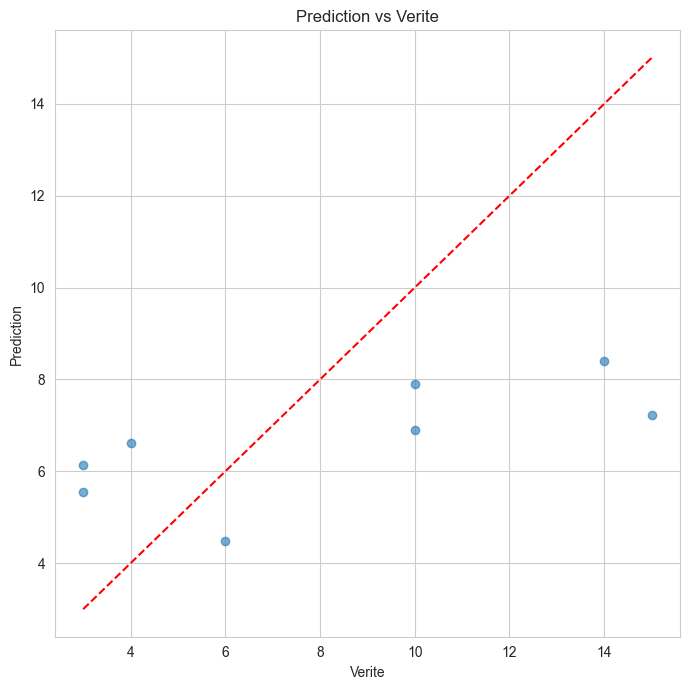

mae     3.550176
rmse    4.052402
r2      0.193396
dtype: float64


,subject_id,n,mae,rmse
0,AP1133,1.0,5.599969,5.599969
1,BM1997,1.0,3.103694,3.103694
2,EL5421,1.0,2.552035,2.552035
3,MD2001,1.0,2.095076,2.095076
4,MM2024,1.0,7.775648,7.775648
5,NT1234,1.0,2.612737,2.612737
6,rl2704,1.0,3.145220,3.145220
7,tt3912,1.0,1.517029,1.517029


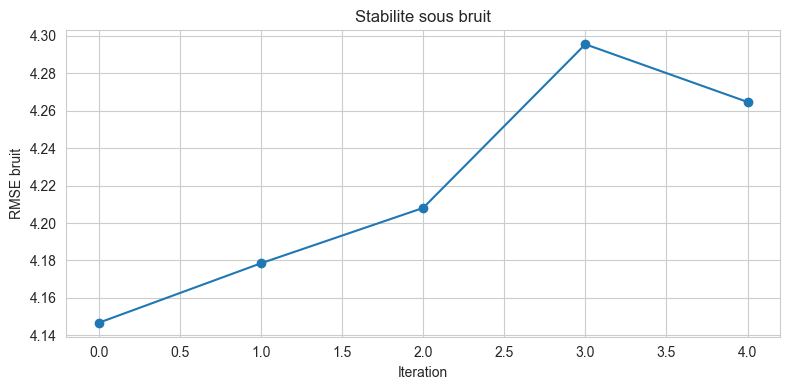

Score robustesse (moyenne): 4.218676887513795


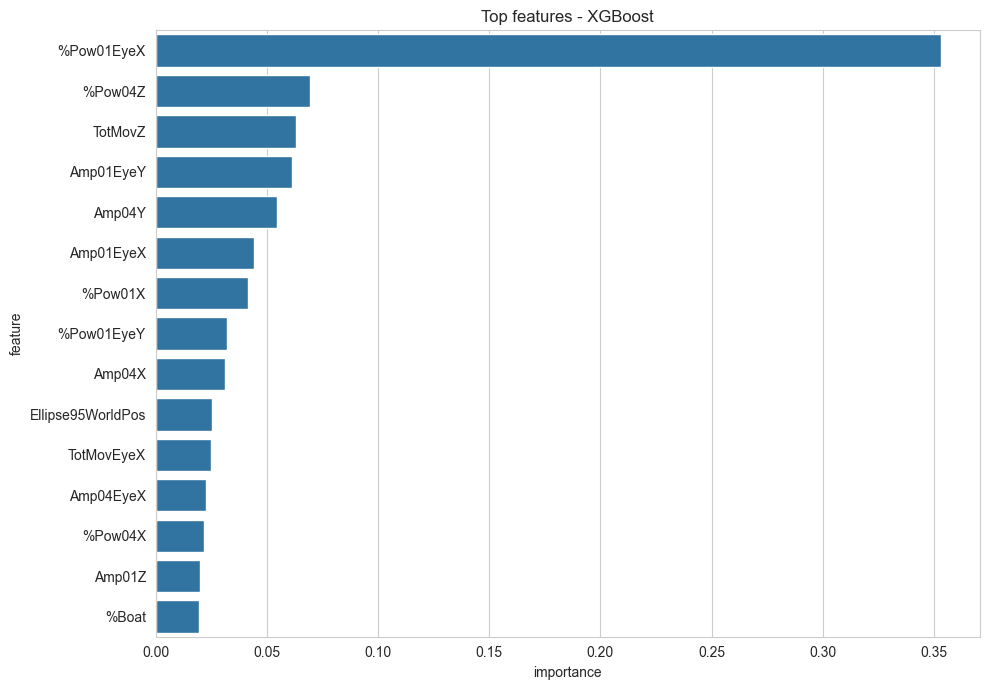

,feature,importance
22,%Pow01EyeX,0.353085
15,%Pow04Z,0.069480
8,TotMovZ,0.063288
17,Amp01EyeY,0.061488
4,Amp04Y,0.054485
16,Amp01EyeX,0.044028
10,%Pow01X,0.041506
23,%Pow01EyeY,0.031961
3,Amp04X,0.031238
27,Ellipse95WorldPos,0.025470


In [ ]:
pred_test, metrics, classification_text_report = evaluate_test_set(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    show_plots=True,
)

print(pd.Series(metrics))
if classification_text_report is not None:
    print("\nClassification report:")
    print(classification_text_report)

by_subject = evaluate_by_subject(
    dataset_df=dataset_df,
    test_idx=test_idx,
    y_test=y_test,
    pred_test=pred_test,
    model_profile=MODEL_PROFILE,
)
display(by_subject.head(20))

noise_scores = evaluate_robustness(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    eval_profile=EVAL_PROFILE,
    seed=SEED,
    show_plot=True,
)
print("Score robustesse (moyenne):", float(np.mean(noise_scores)))

imp_df = plot_feature_importance(final_model, feature_cols, top_n=15)
if imp_df is not None:
    display(imp_df.head(20))

plot_pca_if_classification(X_test_imp, y_test, MODEL_PROFILE, seed=SEED)

## 8) Fiche modele (model card)

In [ ]:
model_card = build_model_card(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    representation_profile=REPRESENTATION_PROFILE,
    data_profile=DATA_PROFILE,
    best_params=best_params,
    metrics=metrics,
    noise_scores=noise_scores,
)

display(pd.DataFrame([{"field": k, "value": str(v)} for k, v in model_card.items()]))

if OUTPUT_PROFILE.get("save_model_card", True):
    card_json, results_csv = save_outputs(model_card, results_df, OUTPUT_PROFILE)
    print("Fichiers sauvegardes:")
    print("-", card_json)
    print("-", results_csv)

,field,value
0,model_name,XGBoost
1,task_type,regression
2,approach,A
3,data_source,csv
4,dataset,../data/Indicateurs calculés/FullTimeIndicator...
5,mat_variable,None
6,n_samples,39
7,n_subjects,39
8,n_features,31
9,split_method,random


Fichiers sauvegardes:
- ../outputs/xgboost_modulaire\model_card_xgboost.json
- ../outputs/xgboost_modulaire\hyperparam_search_results.csv
